# Figures for README

Generates the two publication ready plots used in `README.md`:

1. **ROC curves** — all 5 models on one chart
2. **Window size ablation** — AUC-ROC vs temporal context length

Also produces two deeper analysis plots that live in this notebook only:

3. **AE reconstruction error histogram** — empty vs occupied distributions
4. **LR prediction timeline** — predicted probability over session-2 windows

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

SAVE_DIR  = 'feasibility-study-outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "sans-serif",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "legend.fontsize":   10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})

In [2]:
roc_lr          = np.load("plot_data/roc_lr.npz")
roc_cnn         = np.load("plot_data/roc_cnn.npz")
roc_transformer = np.load("plot_data/roc_transformer.npz")
roc_ae          = np.load("plot_data/roc_ae.npz")
roc_ocsvm       = np.load("plot_data/roc_ocsvm.npz")
ae_err          = np.load("plot_data/ae_errors.npz")
lr_tl           = np.load("plot_data/lr_timeline.npz")
ablation        = np.load("plot_data/ablation.npz")

for name, d in [("roc_lr", roc_lr), ("roc_cnn", roc_cnn),
                ("roc_transformer", roc_transformer), ("roc_ae", roc_ae),
                ("roc_ocsvm", roc_ocsvm)]:
    print(f"  {name}: AUC = {float(d['auc'][0]):.3f}")

  roc_lr: AUC = 0.640
  roc_cnn: AUC = 0.577
  roc_transformer: AUC = 0.602
  roc_ae: AUC = 0.748
  roc_ocsvm: AUC = 0.655


## Plot 1 — ROC Curves (README figure)

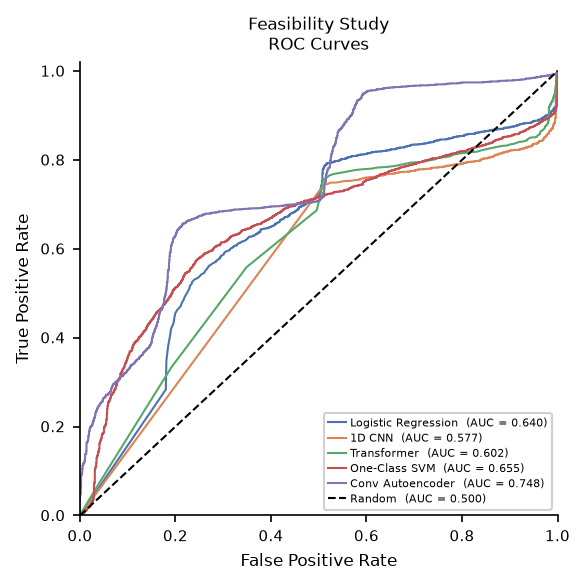

In [58]:
# -- text sizes ---
FS_TITLE  = 8
FS_LABEL  = 8
FS_TICK   = 7
FS_LEGEND = 5.5

fig, ax = plt.subplots(figsize=(4, 4))

MODELS = [
    ("Logistic Regression",  roc_lr,          "#4C72B0",  "-"),
    ("1D CNN",               roc_cnn,          "#DD8452", "-"),
    ("Transformer",          roc_transformer,  "#55A868", "-"),
    ("One-Class SVM",        roc_ocsvm,        "#C44E52", "-"),
    ("Conv Autoencoder",     roc_ae,           "#8172B2", "-"),
]

for name, data, color, ls in MODELS:
    auc = float(data["auc"][0])
    ax.plot(data["fpr"], data["tpr"],
            color=color, lw=1, linestyle=ls,
            label=f"{name}  (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], color="#000000", lw=1, label="Random  (AUC = 0.500)", linestyle="--")

ax.set_xlabel("False Positive Rate", fontsize=FS_LABEL)
ax.set_ylabel("True Positive Rate",  fontsize=FS_LABEL)
ax.tick_params(axis='both', labelsize=FS_TICK)
ax.set_title("Feasibility Study\nROC Curves", fontsize=FS_TITLE)
ax.legend(loc="lower right", framealpha=0.9, fontsize=FS_LEGEND,
          borderpad=0.4, labelspacing=0.3, handlelength=1.5, handletextpad=0.4)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/08_roc_all_models.png', dpi=150, bbox_inches='tight')
plt.show()  

## Plot 2 — Window Size Ablation (README figure)

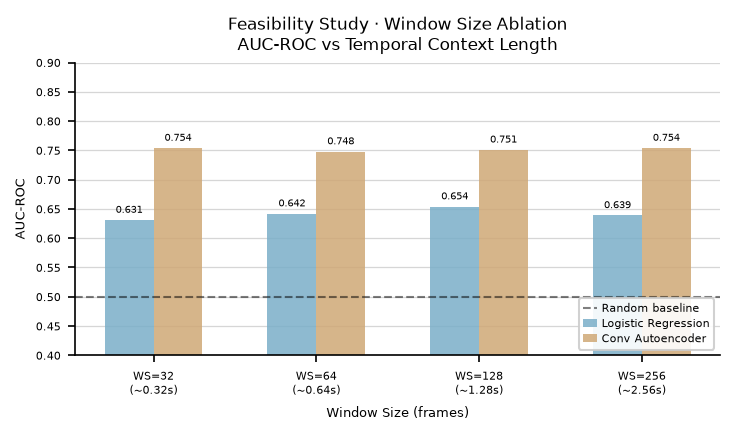

In [ ]:
ws   = ablation["window_sizes"]
lr_a = ablation["lr_aucs"]
ae_a = ablation["ae_aucs"]

x     = np.arange(len(ws))
width = 0.30

# -- text sizes ------- width
FS_TITLE  = 8
FS_LABEL  = 6
FS_TICK   = 5.5
FS_BAR    = 5
FS_LEGEND = 5.5

fig, ax = plt.subplots(figsize=(5, 3))
ax.set_axisbelow(True)
ax.yaxis.grid(True, linewidth=0.6, color='#cccccc', alpha=0.8)

bars_lr = ax.bar(x - width/2, lr_a, width, label="Logistic Regression", color='#7AAEC8', alpha=0.85)
bars_ae = ax.bar(x + width/2, ae_a, width, label="Conv Autoencoder",     color='#CFA876', alpha=0.85)

ax.axhline(0.5, color="black", linestyle="--", lw=1, alpha=0.5, label="Random baseline")

for bar in bars_lr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=FS_BAR, zorder=5)
for bar in bars_ae:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=FS_BAR, zorder=5)

ax.set_xticks(x)
ax.set_xticklabels([f"WS={w}\n(~{w/100:.2f}s)" for w in ws], fontsize=FS_TICK)
ax.tick_params(axis='y', labelsize=FS_TICK)
ax.set_xlabel("Window Size (frames)", fontsize=FS_LABEL)
ax.set_ylabel("AUC-ROC",              fontsize=FS_LABEL)
ax.set_ylim(0.40, 0.90)
ax.yaxis.set_major_locator(plt.MaxNLocator(12))
ax.set_title("Feasibility Study · Window Size Ablation\nAUC-ROC vs Temporal Context Length", fontsize=FS_TITLE)
ax.legend(framealpha=0.9, loc="lower right", fontsize=FS_LEGEND,
          borderpad=0.4, labelspacing=0.3, handlelength=1.2, handletextpad=0.4)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/09_window_size_ablation.png', dpi=150, bbox_inches='tight')
plt.show() 

## Plot 3 — AE Reconstruction Error Distribution (notebook-only)

Histogram of per-window reconstruction errors for empty vs occupied frames,
with the detection threshold marked. Shows how well the autoencoder separates
the two classes in error space.

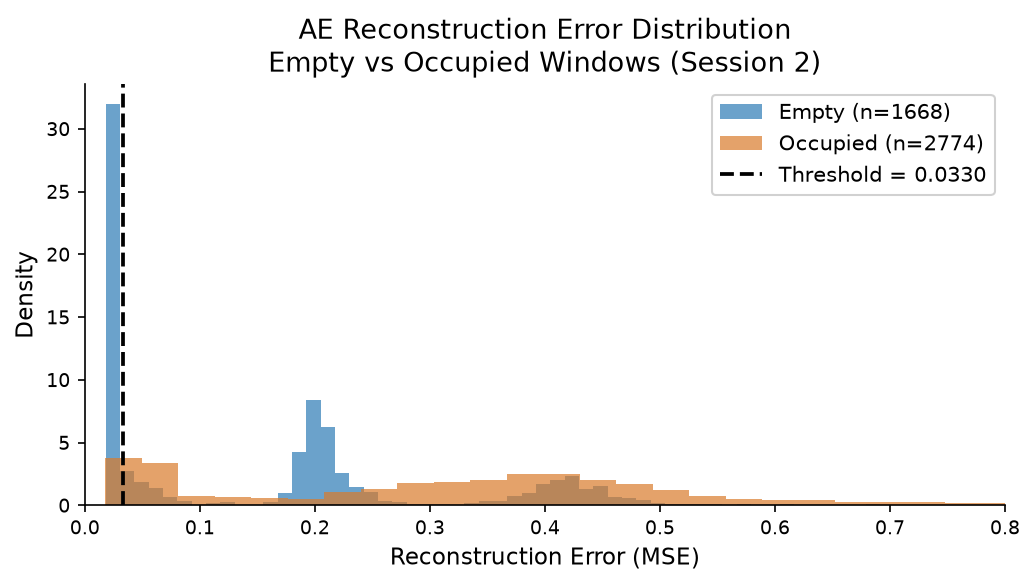

In [39]:
ae = np.load("plot_data/ae_errors.npz")
errors    = ae["errors"]
labels    = ae["labels"]
threshold = float(ae["threshold"].flat[0])

empty_err    = errors[labels == 0]
occupied_err = errors[labels == 1]

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(empty_err,    bins=60, alpha=0.7, color='#2C7BB6', label=f"Empty (n={len(empty_err)})",       density=True)
ax.hist(occupied_err, bins=60, alpha=0.7, color='#D97B2B', label=f"Occupied (n={len(occupied_err)})", density=True)
ax.axvline(threshold, color="black", linestyle="--", lw=1.8, label=f"Threshold = {threshold:.4f}")

ax.set_xlabel("Reconstruction Error (MSE)")
ax.set_ylabel("Density")
ax.set_title("AE Reconstruction Error Distribution\nEmpty vs Occupied Windows (Session 2)")
ax.legend(framealpha=0.9)
ax.set_xlim(0, 0.8)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/09_ae_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 4 — LR Predicted Probability Timeline (notebook-only)

LR positive-class probability over the sequence of session-2 windows,
coloured by ground truth label. Shows temporal structure in predictions
and where the model struggles.

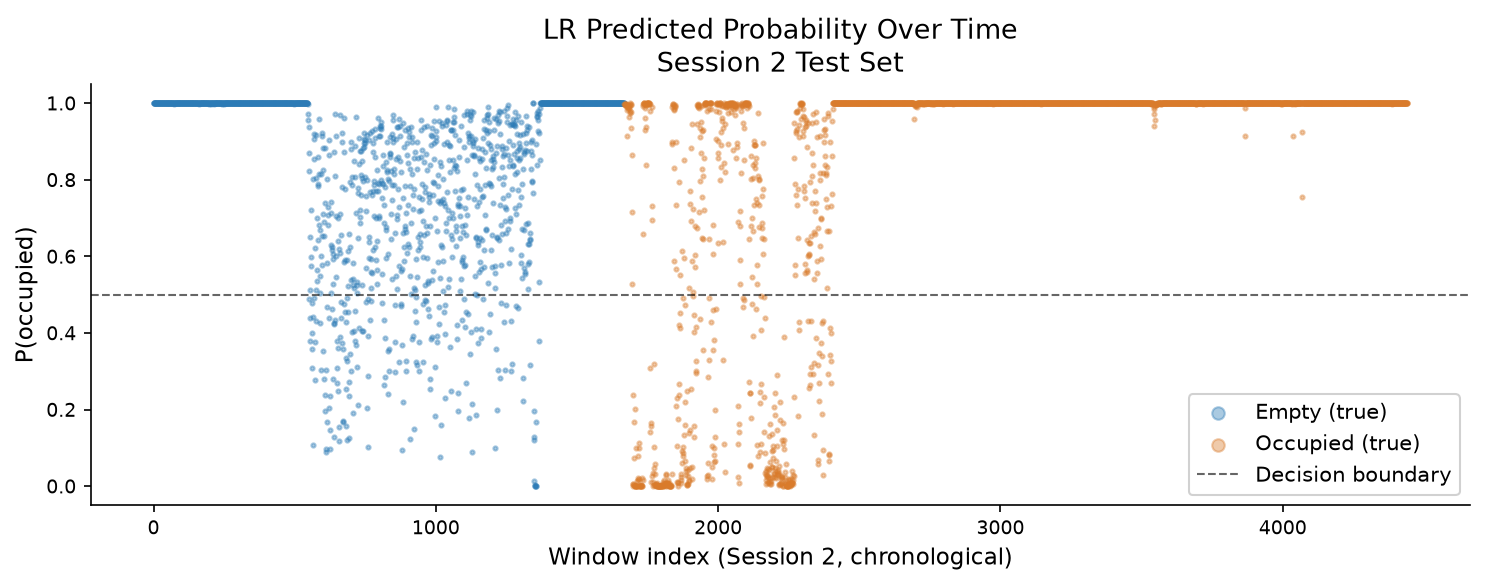

In [40]:
lr = np.load("plot_data/lr_timeline.npz")
y_true = lr["y_true"]
y_prob  = lr["y_prob"]

fig, ax = plt.subplots(figsize=(10, 4))

t = np.arange(len(y_prob))
ax.scatter(t[y_true == 0], y_prob[y_true == 0],
           s=4, alpha=0.4, color='#2C7BB6', label="Empty (true)")
ax.scatter(t[y_true == 1], y_prob[y_true == 1],
           s=4, alpha=0.4, color='#D97B2B', label="Occupied (true)")
ax.axhline(0.5, color="black", linestyle="--", lw=1, alpha=0.6, label="Decision boundary")

ax.set_xlabel("Window index (Session 2, chronological)")
ax.set_ylabel("P(occupied)")
ax.set_title("LR Predicted Probability Over Time\nSession 2 Test Set")
ax.legend(markerscale=3, framealpha=0.9)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/08_lr_timeline.png', dpi=150, bbox_inches='tight')
plt.show()